In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
#import instacart.csv/par

df_instacart = pd.read_parquet("../data/processed/instacart.parquet")
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [19]:
df_instacart.shape

(1384706, 22)

In [20]:
df_instacart.describe()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,prices,Age,n_dependants,income
count,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384618e+06,1.384706e+06,1.384706e+06,1.384706e+06
mean,1.706298e+06,1.709135e+01,2.701394e+00,1.357761e+01,1.706626e+01,8.758180e+00,5.985964e-01,1.411711e+01,4.938182e+01,1.498778e+00,9.766228e+04
std,9.897342e+05,1.661400e+01,2.167637e+00,4.238461e+00,1.042639e+01,7.423973e+00,4.901825e-01,6.802253e+02,1.843685e+01,1.117567e+00,4.199139e+04
min,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00,2.591100e+04
25%,8.433700e+05,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,3.000000e+00,0.000000e+00,4.300000e+00,3.300000e+01,0.000000e+00,6.485900e+04
50%,1.701880e+06,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,7.000000e+00,1.000000e+00,7.400000e+00,4.900000e+01,1.000000e+00,9.576500e+04
75%,2.568023e+06,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,1.200000e+01,1.000000e+00,1.130000e+01,6.500000e+01,2.000000e+00,1.268178e+05
max,3.421070e+06,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,8.000000e+01,1.000000e+00,9.999900e+04,8.100000e+01,3.000000e+00,5.910890e+05


In [21]:
# Data preparation
orders_by_dow = (df_instacart[['order_id', 'order_dow']]
                 .drop_duplicates()
                 .groupby('order_dow')
                 .size()
                 )
type(orders_by_dow)


pandas.Series

In [22]:
d = pd.DataFrame(orders_by_dow).reset_index()
d

,order_dow,0
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


In [23]:
d.columns

Index(['order_dow', 0], dtype='object')

In [24]:
d.rename(columns={0:'number_of_orders'},inplace=True)
d

,order_dow,number_of_orders
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


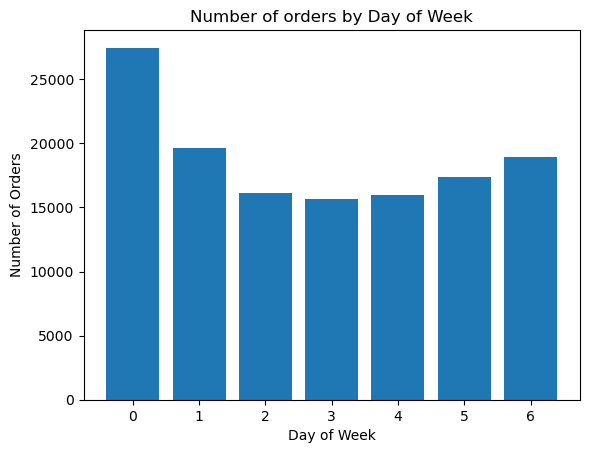

In [25]:
plt.Figure()
plt.bar(orders_by_dow.index,orders_by_dow.values)
plt.title('Number of orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

In [26]:
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='str')

In [27]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby(["order_dow"])
    .size()
)

orders_by_day

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

In [31]:
df = orders_by_day.reset_index()

In [33]:
df.rename(columns={0:'number_of_orders'},inplace=True)
df.head()

,order_dow,number_of_orders
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959


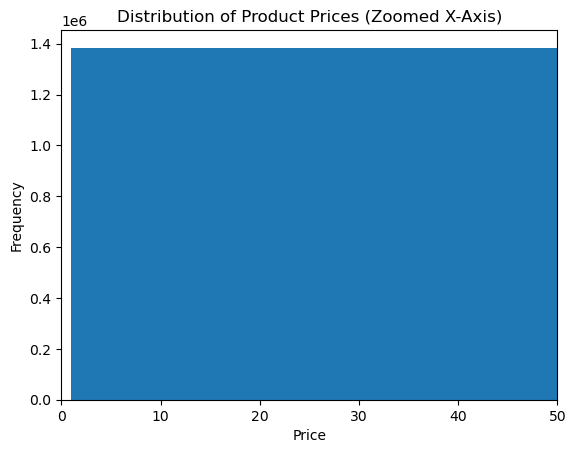

In [ ]:
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=5)
plt.xlim(0, 50)
plt.title("Distribution of Product Prices (Zoomed X-Axis)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [40]:
df_instacart.describe()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,prices,Age,n_dependants,income
count,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384618e+06,1.384706e+06,1.384706e+06,1.384706e+06
mean,1.706298e+06,1.709135e+01,2.701394e+00,1.357761e+01,1.706626e+01,8.758180e+00,5.985964e-01,1.411711e+01,4.938182e+01,1.498778e+00,9.766228e+04
std,9.897342e+05,1.661400e+01,2.167637e+00,4.238461e+00,1.042639e+01,7.423973e+00,4.901825e-01,6.802253e+02,1.843685e+01,1.117567e+00,4.199139e+04
min,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00,2.591100e+04
25%,8.433700e+05,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,3.000000e+00,0.000000e+00,4.300000e+00,3.300000e+01,0.000000e+00,6.485900e+04
50%,1.701880e+06,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,7.000000e+00,1.000000e+00,7.400000e+00,4.900000e+01,1.000000e+00,9.576500e+04
75%,2.568023e+06,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,1.200000e+01,1.000000e+00,1.130000e+01,6.500000e+01,2.000000e+00,1.268178e+05
max,3.421070e+06,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,8.000000e+01,1.000000e+00,9.999900e+04,8.100000e+01,3.000000e+00,5.910890e+05
